In [1]:
# 03_labeling.ipynb - Створення міток якості сесій (ОПТИМІЗОВАНО)

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from src.config import DATA_DIR, FIGURES_DIR
from src.data_loader import load_clicks, load_buys

%matplotlib inline

# Налаштування
plt.rcParams['figure.figsize'] = (12, 6)
(FIGURES_DIR / 'labeling').mkdir(parents=True, exist_ok=True)

print("="*60)
print("СТВОРЕННЯ МІТОК ЯКОСТІ СЕСІЙ (оптимізовано)")
print("="*60)

СТВОРЕННЯ МІТОК ЯКОСТІ СЕСІЙ (оптимізовано)


In [2]:
print("Завантаження даних...")

# Оптимізоване завантаження з dtype
clicks = load_clicks()
buys = load_buys()

print(f"\n✅ Clicks: {len(clicks):,} записів")
print(f"✅ Buys: {len(buys):,} записів")

# Підрахунок сесій (швидко)
n_sessions = clicks['Session_ID'].nunique()
print(f"✅ Унікальних сесій: {n_sessions:,}")

# Сортування з використанням ефективної пам'яті
print("\nСортування даних...")
clicks = clicks.sort_values(['Session_ID', 'Timestamp'])
clicks['event_order'] = clicks.groupby('Session_ID', sort=False).cumcount() + 1

print("✅ Готово")

Завантаження даних...

✅ Clicks: 33,003,944 записів
✅ Buys: 1,150,753 записів
✅ Унікальних сесій: 9,249,729

Сортування даних...
✅ Готово


In [3]:
print("="*60)
print("ВИЗНАЧЕННЯ МЕТОДУ ОЦІНКИ ЯКОСТІ")
print("="*60)

print("""
МОЖЛИВІ ПІДХОДИ ДО ВИЗНАЧЕННЯ ЯКІСНОЇ СЕСІЇ:

1️⃣ RULE-BASED (ПРАВИЛА):
   - Наявність покупки
   - Кількість переглядів > порогу
   - Різноманітність категорій
   - Тривалість сесії

2️⃣ GOAL-BASED (НА ОСНОВІ ЦІЛЕЙ):
   - Досягнення певної дії (додавання в кошик, покупка)
   - Виконання цільових подій

3️⃣ CLUSTERING (КЛАСТЕРИЗАЦІЯ):
   - Групування схожих сесій
   - Визначення якісних кластерів

4️⃣ HYBRID (КОМБІНОВАНИЙ):
   - Комбінація правил + кластеризація
""")

# ВИБЕРІТЬ ОДИН З ПІДХОДІВ
APPROACH = "rule_based"  # Змініть тут: "rule_based", "goal_based", "clustering"

print(f"\n✅ Обраний підхід: {APPROACH}")

ВИЗНАЧЕННЯ МЕТОДУ ОЦІНКИ ЯКОСТІ

МОЖЛИВІ ПІДХОДИ ДО ВИЗНАЧЕННЯ ЯКІСНОЇ СЕСІЇ:

1️⃣ RULE-BASED (ПРАВИЛА):
   - Наявність покупки
   - Кількість переглядів > порогу
   - Різноманітність категорій
   - Тривалість сесії

2️⃣ GOAL-BASED (НА ОСНОВІ ЦІЛЕЙ):
   - Досягнення певної дії (додавання в кошик, покупка)
   - Виконання цільових подій

3️⃣ CLUSTERING (КЛАСТЕРИЗАЦІЯ):
   - Групування схожих сесій
   - Визначення якісних кластерів

4️⃣ HYBRID (КОМБІНОВАНИЙ):
   - Комбінація правил + кластеризація


✅ Обраний підхід: rule_based


In [4]:
print("="*60)
print("ПІДГОТОВКА ДАНИХ")
print("="*60)

# Створюємо агреговані характеристики сесій
session_features = clicks.groupby('Session_ID').agg({
    'Item_ID': ['count', 'nunique'],
    'Category': 'nunique',
    'event_order': 'max',
    'Timestamp': lambda x: (x.max() - x.min()).total_seconds() / 60  # тривалість в хвилинах
}).reset_index()

# Перейменовуємо колонки
session_features.columns = ['Session_ID', 'total_clicks', 'unique_items', 'unique_categories', 
                            'session_length_events', 'duration_minutes']

# Додаємо інформацію про покупки
if len(buys) > 0:
    purchases_per_session = buys.groupby('Session_ID').size().reset_index(name='num_purchases')
    session_features = session_features.merge(purchases_per_session, on='Session_ID', how='left')
    session_features['num_purchases'] = session_features['num_purchases'].fillna(0)
    session_features['has_purchase'] = (session_features['num_purchases'] > 0).astype(int)
else:
    session_features['num_purchases'] = 0
    session_features['has_purchase'] = 0

# Додаємо часові ознаки
session_times = clicks.groupby('Session_ID')['Timestamp'].agg(['min', 'max']).reset_index()
session_times['hour'] = session_times['min'].dt.hour
session_times['day_of_week'] = session_times['min'].dt.dayofweek
session_times['is_weekend'] = (session_times['day_of_week'] >= 5).astype(int)

session_features = session_features.merge(session_times[['Session_ID', 'hour', 'day_of_week', 'is_weekend']], 
                                          on='Session_ID', how='left')

print(f"\n✅ Створено {len(session_features)} записів з характеристиками сесій")
print(f"\nХарактеристики сесій:")
session_features.head()

ПІДГОТОВКА ДАНИХ

✅ Створено 9249729 записів з характеристиками сесій

Характеристики сесій:


,Session_ID,total_clicks,unique_items,unique_categories,session_length_events,duration_minutes,num_purchases,has_purchase,hour,day_of_week,is_weekend
0,1,4,4,1,4,5.850483,0.0,0,10,0,0
1,2,6,5,1,6,5.987917,0.0,0,13,0,0
2,3,3,3,1,3,12.422967,0.0,0,13,2,0
3,4,2,2,1,2,17.241133,0.0,0,12,0,0
4,6,2,2,1,2,4.102133,0.0,0,16,6,1


In [5]:
print("="*60)
print("RULE-BASED LABELING")
print("="*60)

if APPROACH == "rule_based":
    
    # Визначаємо правила (можна налаштовувати)
    print("\n📋 ПРАВИЛА ДЛЯ ВИЗНАЧЕННЯ ЯКІСНОЇ СЕСІЇ:")
    
    # Правило 1: Наявність покупки (основне)
    RULE_HAS_PURCHASE = True
    print(f"  Правило 1: Сесія має покупку - {RULE_HAS_PURCHASE}")
    
    # Правило 2: Мінімальна кількість переглядів
    MIN_CLICKS = 3
    print(f"  Правило 2: Мінімум {MIN_CLICKS} переглядів")
    
    # Правило 3: Різноманітність категорій
    MIN_CATEGORIES = 2
    print(f"  Правило 3: Мінімум {MIN_CATEGORIES} різних категорій")
    
    # Правило 4: Мінімальна тривалість сесії (хвилини)
    MIN_DURATION = 1
    print(f"  Правило 4: Мінімум {MIN_DURATION} хвилина тривалості")
    
    # Правило 5: Не надто довга сесія (аномалії)
    MAX_CLICKS = 100
    print(f"  Правило 5: Не більше {MAX_CLICKS} переглядів (виключаємо аномалії)")
    
    # Застосовуємо правила
    session_features['quality_score'] = 0
    
    # Початкова оцінка
    session_features['quality_score'] += session_features['has_purchase'] * 50  # покупка дає 50 балів
    session_features['quality_score'] += np.minimum(session_features['total_clicks'] / 10, 20)  # до 20 балів за кліки
    session_features['quality_score'] += np.minimum(session_features['unique_categories'] * 5, 20)  # до 20 балів за категорії
    session_features['quality_score'] += np.minimum(session_features['duration_minutes'] / 5, 10)  # до 10 балів за тривалість
    
    # Штрафи за аномалії
    session_features.loc[session_features['total_clicks'] > MAX_CLICKS, 'quality_score'] *= 0.5
    
    # Визначаємо якісні сесії (поріг 50 балів)
    QUALITY_THRESHOLD = 50
    session_features['is_quality_session'] = (session_features['quality_score'] >= QUALITY_THRESHOLD).astype(int)
    
    print(f"\n📊 Результати labeling:")
    print(f"  Поріг якості: {QUALITY_THRESHOLD} балів")
    print(f"  Якісних сесій: {session_features['is_quality_session'].sum():,}")
    print(f"  Неякісних сесій: {(~session_features['is_quality_session'].astype(bool)).sum():,}")
    print(f"  Відсоток якісних: {session_features['is_quality_session'].mean()*100:.2f}%")
    
    # Показуємо приклади
    print("\n📝 ПРИКЛАДИ СЕСІЙ:")
    print("\nЯкісні сесії (топ-5):")
    quality_examples = session_features[session_features['is_quality_session'] == 1].nlargest(5, 'quality_score')
    display(quality_examples[['Session_ID', 'total_clicks', 'unique_categories', 'has_purchase', 
                              'duration_minutes', 'quality_score']])
    
    print("\nНеякісні сесії (топ-5):")
    low_quality_examples = session_features[session_features['is_quality_session'] == 0].nsmallest(5, 'quality_score')
    display(low_quality_examples[['Session_ID', 'total_clicks', 'unique_categories', 'has_purchase', 
                                  'duration_minutes', 'quality_score']])

RULE-BASED LABELING

📋 ПРАВИЛА ДЛЯ ВИЗНАЧЕННЯ ЯКІСНОЇ СЕСІЇ:
  Правило 1: Сесія має покупку - True
  Правило 2: Мінімум 3 переглядів
  Правило 3: Мінімум 2 різних категорій
  Правило 4: Мінімум 1 хвилина тривалості
  Правило 5: Не більше 100 переглядів (виключаємо аномалії)

📊 Результати labeling:
  Поріг якості: 50 балів
  Якісних сесій: 509,608
  Неякісних сесій: 8,740,121
  Відсоток якісних: 5.51%

📝 ПРИКЛАДИ СЕСІЙ:

Якісні сесії (топ-5):


,Session_ID,total_clicks,unique_categories,has_purchase,duration_minutes,quality_score
6862590,8578238,98,5,1,146.456567,89.8
5327944,6659931,97,5,1,79.998700,89.7
6892576,8615721,95,7,1,213.189567,89.5
7924392,9905491,95,7,1,249.748183,89.5
5164296,6455371,94,5,1,66.560467,89.4



Неякісні сесії (топ-5):


,Session_ID,total_clicks,unique_categories,has_purchase,duration_minutes,quality_score
66,83,1,1,0,0.0,5.1
67,84,1,1,0,0.0,5.1
120,151,1,1,0,0.0,5.1
121,152,1,1,0,0.0,5.1
170,213,1,1,0,0.0,5.1


In [6]:
print("="*60)
print("GOAL-BASED LABELING")
print("="*60)

if APPROACH == "goal_based":
    
    # Визначаємо цілі
    GOALS = {
        'purchase': 10,        # покупка = 10 балів
        'view_count': 5,       # кожні 5 переглядів = 1 бал
        'category_diversity': 3,  # кожна нова категорія = 3 бали
        'long_session': 2      # сесія довша 5 хвилин = 2 бали
    }
    
    print("\n🎯 ВИЗНАЧЕНІ ЦІЛІ:")
    for goal, weight in GOALS.items():
        print(f"  {goal}: вага {weight}")
    
    # Розрахунок цільових балів
    session_features['goal_score'] = 0
    session_features['goal_score'] += session_features['has_purchase'] * GOALS['purchase']
    session_features['goal_score'] += (session_features['total_clicks'] // GOALS['view_count']) * 1
    session_features['goal_score'] += session_features['unique_categories'] * GOALS['category_diversity']
    session_features['goal_score'] += (session_features['duration_minutes'] > 5).astype(int) * GOALS['long_session']
    
    # Нормалізація до [0, 1]
    max_score = session_features['goal_score'].max()
    session_features['goal_score_norm'] = session_features['goal_score'] / max_score
    
    # Визначаємо якісні сесії (топ 30%)
    QUALITY_PERCENTILE = 70  # топ 30% за балом
    threshold = session_features['goal_score'].quantile(QUALITY_PERCENTILE / 100)
    session_features['is_quality_session'] = (session_features['goal_score'] >= threshold).astype(int)
    
    print(f"\n📊 Результати labeling:")
    print(f"  Відсоток якісних сесій: {100 - QUALITY_PERCENTILE}%")
    print(f"  Якісних сесій: {session_features['is_quality_session'].sum():,}")
    print(f"  Неякісних сесій: {(~session_features['is_quality_session'].astype(bool)).sum():,}")

GOAL-BASED LABELING


In [7]:
print("="*60)
print("CLUSTERING-BASED LABELING")
print("="*60)

if APPROACH == "clustering":
    
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    
    # Вибираємо ознаки для кластеризації
    features_for_clustering = ['total_clicks', 'unique_items', 'unique_categories', 
                               'duration_minutes', 'has_purchase', 'hour']
    
    # Підготовка даних
    X = session_features[features_for_clustering].fillna(0)
    
    # Стандартизація
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Визначаємо оптимальну кількість кластерів (Elbow method)
    inertias = []
    K_range = range(2, 11)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
    
    # Візуалізація Elbow
    plt.figure(figsize=(10, 5))
    plt.plot(K_range, inertias, 'bo-')
    plt.xlabel('Кількість кластерів')
    plt.ylabel('Інерція')
    plt.title('Elbow Method для визначення оптимальної кількості кластерів')
    plt.grid(True, alpha=0.3)
    plt.savefig(FIGURES_DIR / 'labeling/elbow_method.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Обираємо кількість кластерів
    n_clusters = 4  # Можна змінити на основі Elbow
    print(f"\n📊 Обрано {n_clusters} кластерів")
    
    # Кластеризація
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    session_features['cluster'] = kmeans.fit_predict(X_scaled)
    
    # Аналіз кластерів
    print("\n📊 ХАРАКТЕРИСТИКИ КЛАСТЕРІВ:")
    cluster_analysis = session_features.groupby('cluster').agg({
        'total_clicks': 'mean',
        'has_purchase': 'mean',
        'duration_minutes': 'mean',
        'unique_categories': 'mean',
        'Session_ID': 'count'
    }).round(2)
    cluster_analysis.columns = ['avg_clicks', 'purchase_rate', 'avg_duration', 'avg_categories', 'count']
    display(cluster_analysis)
    
    # Визначаємо якісні кластери (з високою purchase_rate)
    quality_threshold = 0.3  # покупки в >30% сесій кластера
    quality_clusters = cluster_analysis[cluster_analysis['purchase_rate'] > quality_threshold].index.tolist()
    
    session_features['is_quality_session'] = session_features['cluster'].isin(quality_clusters).astype(int)
    
    print(f"\n✅ Якісні кластери: {quality_clusters}")
    print(f"📊 Якісних сесій: {session_features['is_quality_session'].sum():,}")
    print(f"📊 Відсоток якісних: {session_features['is_quality_session'].mean()*100:.2f}%")
    
    # Візуалізація кластерів (PCA)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=session_features['cluster'], cmap='viridis', alpha=0.6)
    plt.colorbar(scatter)
    plt.title('Кластеризація сесій')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=session_features['is_quality_session'], cmap='coolwarm', alpha=0.6)
    plt.colorbar(scatter)
    plt.title('Якісні (1) vs Неякісні (0) сесії')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'labeling/clusters_pca.png', dpi=100, bbox_inches='tight')
    plt.show()  

CLUSTERING-BASED LABELING


АНАЛІЗ БАЛАНСУ КЛАСІВ

📊 Розподіл класів:
  Якісні сесії (1): 509,608 (5.51%)
  Неякісні сесії (0): 8,740,121 (94.49%)
  Співвідношення: 1:17.15


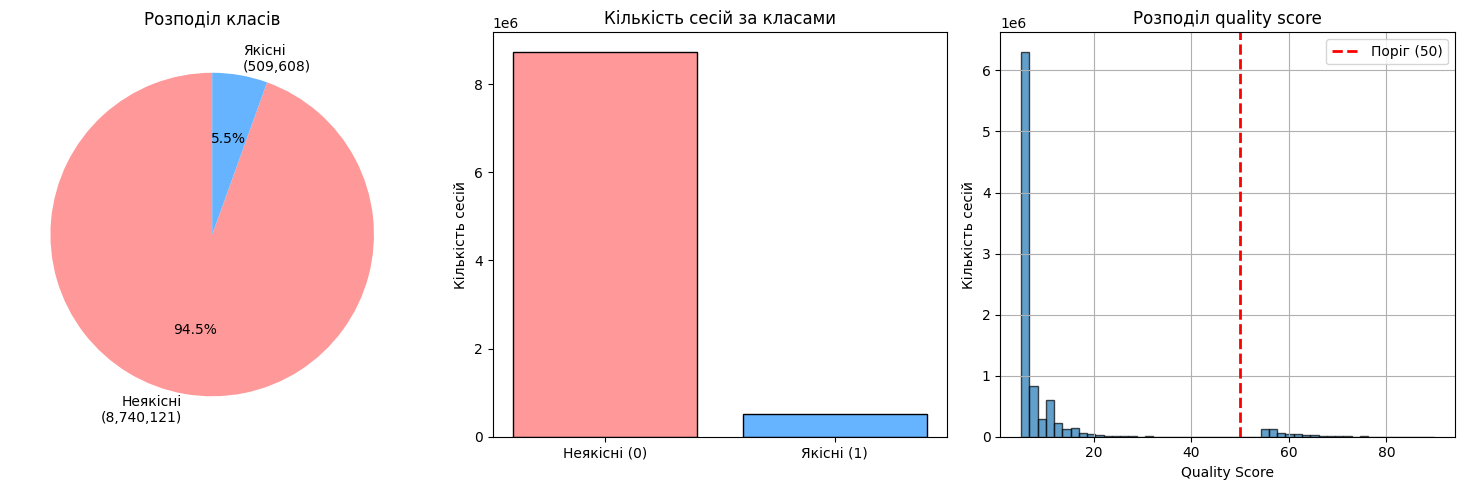


⚠️ УВАГА: Сильний дисбаланс класів!
   Рекомендується:
   - Використовувати class_weight при тренуванні
   - Застосувати oversampling/undersampling
   - Використовувати метрики F1-score, ROC-AUC замість accuracy


In [8]:
print("="*60)
print("АНАЛІЗ БАЛАНСУ КЛАСІВ")
print("="*60)

# Статистика
quality_count = session_features['is_quality_session'].sum()
non_quality_count = len(session_features) - quality_count
quality_ratio = quality_count / len(session_features)

print(f"\n📊 Розподіл класів:")
print(f"  Якісні сесії (1): {quality_count:,} ({quality_ratio*100:.2f}%)")
print(f"  Неякісні сесії (0): {non_quality_count:,} ({(1-quality_ratio)*100:.2f}%)")
print(f"  Співвідношення: 1:{non_quality_count/quality_count:.2f}")

# Візуалізація
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart
colors = ['#ff9999', '#66b3ff']
labels = [f'Неякісні\n({non_quality_count:,})', f'Якісні\n({quality_count:,})']
axes[0].pie([non_quality_count, quality_count], labels=labels, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Розподіл класів')

# Bar chart
axes[1].bar(['Неякісні (0)', 'Якісні (1)'], [non_quality_count, quality_count], 
            color=['#ff9999', '#66b3ff'], edgecolor='black')
axes[1].set_title('Кількість сесій за класами')
axes[1].set_ylabel('Кількість сесій')

# Розподіл quality score
if 'quality_score' in session_features.columns:
    session_features['quality_score'].hist(bins=50, ax=axes[2], edgecolor='black', alpha=0.7)
    axes[2].axvline(QUALITY_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Поріг ({QUALITY_THRESHOLD})')
    axes[2].set_title('Розподіл quality score')
    axes[2].set_xlabel('Quality Score')
    axes[2].set_ylabel('Кількість сесій')
    axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'labeling/class_balance.png', dpi=100, bbox_inches='tight')
plt.show()

# Перевірка на дисбаланс
if quality_ratio < 0.2 or quality_ratio > 0.8:
    print("\n⚠️ УВАГА: Сильний дисбаланс класів!")
    print("   Рекомендується:")
    print("   - Використовувати class_weight при тренуванні")
    print("   - Застосувати oversampling/undersampling")
    print("   - Використовувати метрики F1-score, ROC-AUC замість accuracy")

In [9]:
print("="*60)
print("ЗБЕРЕЖЕННЯ РЕЗУЛЬТАТІВ")
print("="*60)

# Зберігаємо мітки для подальшого використання
labels_df = session_features[['Session_ID', 'is_quality_session', 'quality_score']].copy()

# Додаємо детальну інформацію
if 'cluster' in session_features.columns:
    labels_df['cluster'] = session_features['cluster']

# Зберігаємо в файл
labels_df.to_csv(DATA_DIR / 'session_labels.csv', index=False)
print(f"✅ Мітки збережено в: {DATA_DIR / 'session_labels.csv'}")
print(f"   Формат: Session_ID, is_quality_session, quality_score")

# Зберігаємо повні характеристики сесій
session_features.to_csv(DATA_DIR / 'session_features.csv', index=False)
print(f"✅ Характеристики сесій збережено в: {DATA_DIR / 'session_features.csv'}")

# Зберігаємо метадані labeling
labeling_info = {
    'approach': APPROACH,
    'total_sessions': len(session_features),
    'quality_sessions': int(quality_count),
    'non_quality_sessions': int(non_quality_count),
    'quality_ratio': float(quality_ratio),
    'features_used': features_for_clustering if APPROACH == "clustering" else list(session_features.columns)
}

import json
with open(DATA_DIR / 'labeling_info.json', 'w', encoding='utf-8') as f:
    json.dump(labeling_info, f, indent=4, ensure_ascii=False)

print(f"✅ Інформацію про labeling збережено в: {DATA_DIR / 'labeling_info.json'}")

print("\n" + "="*60)
print("ПІДСУМКИ LABELING")
print("="*60)

print(f"""
Обраний підхід: {APPROACH}
Всього сесій: {len(session_features):,}
Якісних сесій: {quality_count:,} ({quality_ratio*100:.1f}%)
Неякісних сесій: {non_quality_count:,} ({(1-quality_ratio)*100:.1f}%)

Наступний крок: 04_preprocessing.ipynb
- Підготовка даних для моделей
- Формування послідовностей
- Train/val/test split
""")

ЗБЕРЕЖЕННЯ РЕЗУЛЬТАТІВ
✅ Мітки збережено в: d:\University\kursova\kursova\notebooks\..\data\yoochoose\session_labels.csv
   Формат: Session_ID, is_quality_session, quality_score
✅ Характеристики сесій збережено в: d:\University\kursova\kursova\notebooks\..\data\yoochoose\session_features.csv
✅ Інформацію про labeling збережено в: d:\University\kursova\kursova\notebooks\..\data\yoochoose\labeling_info.json

ПІДСУМКИ LABELING

Обраний підхід: rule_based
Всього сесій: 9,249,729
Якісних сесій: 509,608 (5.5%)
Неякісних сесій: 8,740,121 (94.5%)

Наступний крок: 04_preprocessing.ipynb
- Підготовка даних для моделей
- Формування послідовностей
- Train/val/test split



ДОДАТКОВИЙ АНАЛІЗ

📊 ПОРІВНЯННЯ ЯКІСНИХ ТА НЕЯКІСНИХ СЕСІЙ:
                   total_clicks              unique_categories         \
                           mean median   std              mean median   
is_quality_session                                                      
0                          3.40    2.0  3.49              1.13    1.0   
1                          6.46    4.0  6.53              1.31    1.0   

                   duration_minutes        has_purchase  
                               mean median         mean  
is_quality_session                                       
0                              5.89   1.98          0.0  
1                             14.43   7.89          1.0  


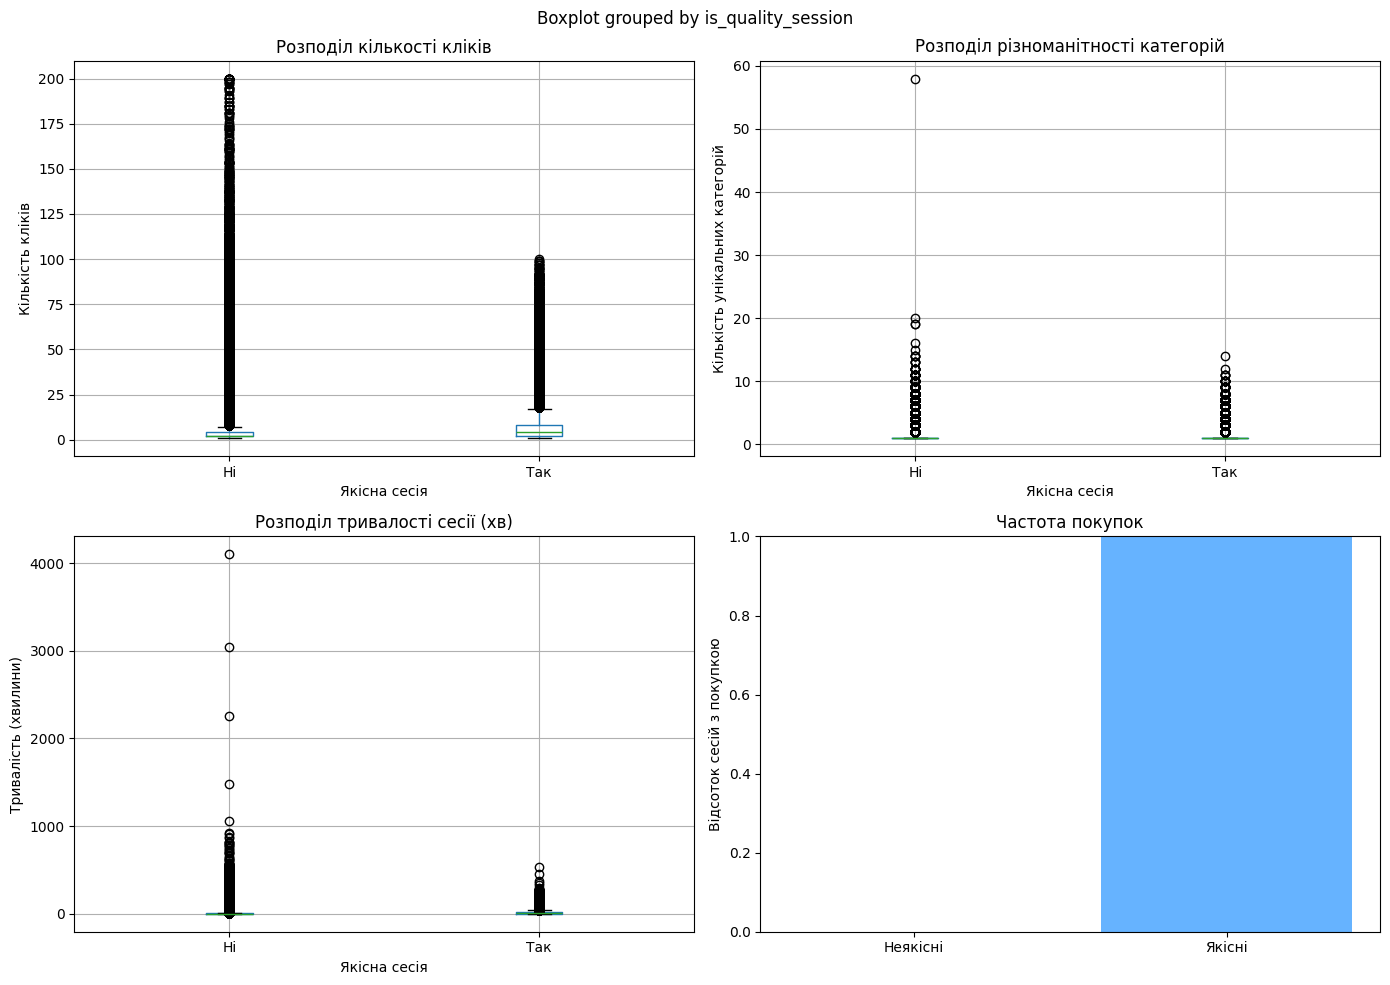


✅ Додатковий аналіз завершено!


In [10]:
print("="*60)
print("ДОДАТКОВИЙ АНАЛІЗ")
print("="*60)

# Порівняння якісних та неякісних сесій
quality_stats = session_features.groupby('is_quality_session').agg({
    'total_clicks': ['mean', 'median', 'std'],
    'unique_categories': ['mean', 'median'],
    'duration_minutes': ['mean', 'median'],
    'has_purchase': 'mean'
}).round(2)

print("\n📊 ПОРІВНЯННЯ ЯКІСНИХ ТА НЕЯКІСНИХ СЕСІЙ:")
print(quality_stats)

# Візуалізація порівняння
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Кількість кліків
session_features.boxplot(column='total_clicks', by='is_quality_session', ax=axes[0,0])
axes[0,0].set_title('Розподіл кількості кліків')
axes[0,0].set_xlabel('Якісна сесія')
axes[0,0].set_ylabel('Кількість кліків')
axes[0,0].set_xticklabels(['Ні', 'Так'])

# Різноманітність категорій
session_features.boxplot(column='unique_categories', by='is_quality_session', ax=axes[0,1])
axes[0,1].set_title('Розподіл різноманітності категорій')
axes[0,1].set_xlabel('Якісна сесія')
axes[0,1].set_ylabel('Кількість унікальних категорій')
axes[0,1].set_xticklabels(['Ні', 'Так'])

# Тривалість сесії
session_features.boxplot(column='duration_minutes', by='is_quality_session', ax=axes[1,0])
axes[1,0].set_title('Розподіл тривалості сесії (хв)')
axes[1,0].set_xlabel('Якісна сесія')
axes[1,0].set_ylabel('Тривалість (хвилини)')
axes[1,0].set_xticklabels(['Ні', 'Так'])

# Частота покупок
purchase_by_quality = session_features.groupby('is_quality_session')['has_purchase'].mean()
axes[1,1].bar(['Неякісні', 'Якісні'], purchase_by_quality, color=['#ff9999', '#66b3ff'])
axes[1,1].set_title('Частота покупок')
axes[1,1].set_ylabel('Відсоток сесій з покупкою')
axes[1,1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'labeling/quality_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ Додатковий аналіз завершено!") 